In [ ]:
import os

# Если ноутбук запущен из notebooks/, поднимаемся в корень проекта,
# чтобы относительные пути ./data, ./models, ./assets работали.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("cwd:", os.getcwd())

import pandas as pd
import numpy as np
import re
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from gensim.models import KeyedVectors, Word2Vec
from pathlib import Path
from datetime import datetime
from collections import Counter
import json
from sklearn.model_selection import GridSearchCV

In [2]:
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10
sns.set_style("whitegrid")

try:
    russian_stopwords = stopwords.words("russian")
    english_stopwords = stopwords.words("english")
except:
    nltk.download("stopwords")
    russian_stopwords = stopwords.words("russian")
    english_stopwords = stopwords.words("english")

In [3]:
train_bodies = pd.read_csv("./data/train_bodies.csv")
test_bodies = pd.read_csv("./data/test_bodies.csv")

train_stances = pd.read_csv("./data/train_stances.csv")
test_stances = pd.read_csv("./data/test_stances_unlebeledb.csv")

In [4]:
train_stances.head(3)

,Unnamed: 0,Body ID,Headline,Stance,Headline1,Headline2
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...


# Проведем предобработку данных

## Объединим данные

In [5]:
train_data = train_stances.merge(train_bodies, on="Body ID", how="left")
test_data = test_stances.merge(test_bodies, on="Body ID", how="left")

In [6]:
train_data.head(3)

,Unnamed: 0_x,Body ID,Headline,Stance,Headline1,Headline2,Unnamed: 0_y,articleBody,articleBody1,articleBody2
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...,0,Разница между ожидаемыми по итогам марта нефте...,разница ожидаемыми итогам марта нефтегазовыми ...,разница ожидать итог март нефтегазовый доход ф...
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка,1,Совет директоров Банка России решил снизить кл...,совет директоров банка россии решил снизить кл...,совет директор банк россия решать снижать ключ...
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...,2,В НАТО составили наступательный план действий ...,нато составили наступательный план действий за...,нато составлять наступательный план действие з...


## Проведем предобработку русского языка

In [7]:
def preprocess_text(text):
    if not isinstance(text, str) or len(text) == 0:
        return ""

    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^а-яё\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    words = [word for word in words if word not in russian_stopwords and len(word) > 2]

    return " ".join(words)


def preprocess_text_en(text):
    if not isinstance(text, str) or len(text) == 0:
        return ""

    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    words = [word for word in words if word not in english_stopwords and len(word) > 2]

    return " ".join(words)

## Обработка заголовков и текстов

In [8]:
eng_data = pd.read_csv("./data/eng_data")

eng_data = eng_data.rename(columns={"title": "Headline", "text": "articleBody"})

eng_data.sample(3)

,Headline,articleBody,label
15515,OK Cop Shoots Family Dog During Child’s Birth...,Noah Malone was celebrating his fifth birthday...,0
21703,Iraqi Kurdish opposition party Gorran calls on...,"BAGHDAD (Reuters) - Gorran, a main opposition ...",1
7518,Myanmar government says case against Reuters j...,YANGON (Reuters) - Myanmar s civilian Presiden...,1


In [9]:
train_data["headline_clean"] = train_data["Headline"].apply(preprocess_text)
train_data["body_clean"] = train_data["articleBody"].apply(preprocess_text)

test_data["headline_clean"] = test_data["Headline"].apply(preprocess_text)
test_data["body_clean"] = test_data["articleBody"].apply(preprocess_text)

eng_data["headline_clean"] = eng_data["Headline"].apply(preprocess_text_en)
eng_data["body_clean"] = eng_data["articleBody"].apply(preprocess_text_en)

In [10]:
eng_data

,Headline,articleBody,label,headline_clean,body_clean
0,Iran's Khamenei warns U.S. against 'wrong move...,DUBAI (Reuters) - Iran will not be bullied by ...,1,iran khamenei warns wrong move nuclear deal,dubai reuters iran bullied united states react...
1,ESPIONAGE ACT VIOLATION? HILLARY EXPOSES Names...,America keeps waiting for word that Hillary wi...,0,espionage act violation hillary exposes names ...,america keeps waiting word hillary indicted ob...
2,SHE’S GOT THE SCOOP! CATHERINE HERRIDGE: “Obam...,,0,got scoop catherine herridge obama put hands s...,
3,Microsoft Pulls New A.I. Robot After It Went o...,Microsoft Pulls Robot After Posted Tweets Like...,0,microsoft pulls new robot went pro hitler twit...,microsoft pulls robot posted tweets like hitle...
4,BLACK CONSERVATIVE Student DESTROYS Black Live...,"If you have the time, you should watch every m...",0,black conservative student destroys black live...,time watch every minute video watch minute mar...
...,...,...,...,...,...
26780,NY Daily News Mocks ‘Bozo’ Trump’s Iowa Caucu...,"Donald Trump, who notoriously called people wh...",0,daily news mocks bozo trump iowa caucus defeat...,donald trump notoriously called people finish ...
26781,Judges consider HK double murder appeal by con...,HONG KONG (Reuters) - Three judges in Hong Kon...,1,judges consider double murder appeal convicted...,hong kong reuters three judges hong kong court...
26782,Malaysia arrests 20 over suspected terror links,KUALA LUMPUR (Reuters) - Malaysia has arrested...,1,malaysia arrests suspected terror links,kuala lumpur reuters malaysia arrested suspect...
26783,Lawmakers Condemn ‘Dangerous Abuse Of Subpoen...,"Only April 28, nearly 100 lawmakers sent a let...",0,lawmakers condemn dangerous abuse subpoena pow...,april nearly lawmakers sent letter marsha blac...


In [11]:
eng_data.sample(3)

,Headline,articleBody,label,headline_clean,body_clean
1971,[VIDEO] SHOULD RINOS AND DEMOCRATS FEAR TRUMP’...,Donald Trump announced he will be running for ...,0,video rinos democrats fear trump presidential ...,donald trump announced running president repub...
21591,"Finally, Obama Speaks: Americans Need to ‘Reco...",21st Century Wire says There is an amazing sce...,0,finally obama speaks americans need reconcile ...,century wire says amazing scene unfolding amer...
20782,WATCH: Trump Lashes Out After Being Grilled T...,George Stephanopoulos allowed presumptive Repu...,0,watch trump lashes grilled breaking point abc ...,george stephanopoulos allowed presumptive repu...


## Создадим комбинированные признаки (заголовок + начало текста)

In [12]:
def combine_features(row):
    headline = row["headline_clean"]
    body_words = row["body_clean"].split()
    body = " ".join(body_words)
    return f"{headline} {body}"

In [13]:
train_data["combined_text"] = train_data.apply(combine_features, axis=1)
test_data["combined_text"] = test_data.apply(combine_features, axis=1)
eng_data["combined_text"] = eng_data.apply(combine_features, axis=1)

In [14]:
train_data = train_data[train_data["combined_text"].str.len() > 10].reset_index(
    drop=True
)
test_data = test_data[test_data["combined_text"].str.len() > 10].reset_index(drop=True)
eng_data = eng_data[eng_data["combined_text"].str.len() > 10].reset_index(drop=True)

In [15]:
train_data["text_length"] = train_data["combined_text"].str.split().str.len()
print(f"\nСтатистика длины комбинированных текстов (в словах):")
print(train_data["text_length"].describe())

train_data_tf = train_data


Статистика длины комбинированных текстов (в словах):
count    4408.000000
mean      136.134528
std        69.050534
min         9.000000
25%       101.000000
50%       126.000000
75%       153.000000
max      1084.000000
Name: text_length, dtype: float64


In [16]:
train_data.iloc[0]

Unnamed: 0_x                                                      0
Body ID                                                           1
Headline          ['российский', 'бюджет', 'марте', 'недополучил...
Stance                                                        agree
Headline1         российский бюджет в марте недополучил более 30...
Headline2         российский бюджет март недополучать миллиард р...
Unnamed: 0_y                                                      0
articleBody       Разница между ожидаемыми по итогам марта нефте...
articleBody1      разница ожидаемыми итогам марта нефтегазовыми ...
articleBody2      разница ожидать итог март нефтегазовый доход ф...
headline_clean    российский бюджет марте недополучил миллиардов...
body_clean        разница ожидаемыми итогам марта нефтегазовыми ...
combined_text     российский бюджет марте недополучил миллиардов...
text_length                                                      73
Name: 0, dtype: object

## Подготовим целевую переменную
---
где:
* Реальная новость - 1
* Фейк - 0

In [17]:
label_mapping = {"agree": 1, "disagree": 0}

train_data["label"] = train_data["Stance"].map(label_mapping)
train_data.head(3)

,Unnamed: 0_x,Body ID,Headline,Stance,Headline1,Headline2,Unnamed: 0_y,articleBody,articleBody1,articleBody2,headline_clean,body_clean,combined_text,text_length,label
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...,0,Разница между ожидаемыми по итогам марта нефте...,разница ожидаемыми итогам марта нефтегазовыми ...,разница ожидать итог март нефтегазовый доход ф...,российский бюджет марте недополучил миллиардов...,разница ожидаемыми итогам марта нефтегазовыми ...,российский бюджет марте недополучил миллиардов...,73,1
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка,1,Совет директоров Банка России решил снизить кл...,совет директоров банка россии решил снизить кл...,совет директор банк россия решать снижать ключ...,банк россии решил снизить ключевую ставку,совет директоров банка россии решил снизить кл...,банк россии решил снизить ключевую ставку сове...,57,1
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...,2,В НАТО составили наступательный план действий ...,нато составили наступательный план действий за...,нато составлять наступательный план действие з...,мыс идокопас нато назвали первую цель начала п...,нато составили наступательный план действий за...,мыс идокопас нато назвали первую цель начала п...,100,0


In [18]:
train_data_tf["label"] = train_data_tf["Stance"].map(label_mapping)
train_data_tf.head(3)

,Unnamed: 0_x,Body ID,Headline,Stance,Headline1,Headline2,Unnamed: 0_y,articleBody,articleBody1,articleBody2,headline_clean,body_clean,combined_text,text_length,label
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...,0,Разница между ожидаемыми по итогам марта нефте...,разница ожидаемыми итогам марта нефтегазовыми ...,разница ожидать итог март нефтегазовый доход ф...,российский бюджет марте недополучил миллиардов...,разница ожидаемыми итогам марта нефтегазовыми ...,российский бюджет марте недополучил миллиардов...,73,1
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка,1,Совет директоров Банка России решил снизить кл...,совет директоров банка россии решил снизить кл...,совет директор банк россия решать снижать ключ...,банк россии решил снизить ключевую ставку,совет директоров банка россии решил снизить кл...,банк россии решил снизить ключевую ставку сове...,57,1
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...,2,В НАТО составили наступательный план действий ...,нато составили наступательный план действий за...,нато составлять наступательный план действие з...,мыс идокопас нато назвали первую цель начала п...,нато составили наступательный план действий за...,мыс идокопас нато назвали первую цель начала п...,100,0


### Удалим все лишнее

In [19]:
train_data.drop(
    columns=[
        "Unnamed: 0_x",
        "Body ID",
        "Headline",
        "Headline1",
        "Headline2",
        "Unnamed: 0_y",
        "articleBody",
        "articleBody1",
        "articleBody2",
        "Stance",
    ],
    inplace=True,
)

In [25]:
train_data.to_csv(path_or_buf="data/ready_dataset.csv", sep=",")

In [19]:
train_data.sample(3)

,headline_clean,body_clean,combined_text,text_length,label
966,заблокировал канал парламентского телевидения ...,видеохостинг заблокировал аккаунт канала дума ...,заблокировал канал парламентского телевидения ...,105,1
3325,кадыров заявил взятии контроль города попасная...,глава чечни рамзан кадыров заявил освобождении...,кадыров заявил взятии контроль города попасная...,111,1
4253,дональд трамп пообещал абрамсу каждому американцу,состоявшемся вашингтоне военном параде честь д...,дональд трамп пообещал абрамсу каждому америка...,106,0


# Word2Vec

## Загрузим эмбеддинги

In [20]:
sentences = [text.split() for text in train_data["body_clean"]] + [
    text.split() for text in train_data["headline_clean"]
]
w2v = Word2Vec(
    sentences, vector_size=300, window=3, min_count=3, sg=1, workers=4, epochs=10
)
kv = w2v.wv

## Функция для получения усреднённого вектора

In [21]:
def doc_vector(tokens, kv_model):
    vecs = [kv_model[w] for w in tokens if w in kv_model]
    if not vecs:
        return np.zeros(kv_model.vector_size, dtype=np.float32)
    return np.vstack(vecs).mean(axis=0)

## Соберем признаки: headline_vec, body_vec, косинусная близость

In [22]:
def cosine(u, v):
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    if nu == 0 or nv == 0:
        return 0.0
    return float(np.dot(u, v) / (nu * nv))


def jaccard(a_tokens, b_tokens):
    A, B = set(a_tokens), set(b_tokens)
    if not A and not B:
        return 0.0
    return len(A & B) / max(1, len(A | B))


def overlap_ratio(a_tokens, b_tokens):
    A, B = set(a_tokens), set(b_tokens)
    if not A:
        return 0.0
    return len(A & B) / len(A)


def elementwise_stats(h_vec, b_vec):
    diff = np.abs(h_vec - b_vec)
    prod = h_vec * b_vec
    l2 = np.linalg.norm(h_vec - b_vec)
    return diff, prod, l2


def build_features(df, kv, max_len=150):
    H, B, COS, JAC, OVR, L2, DIFF, PROD = [], [], [], [], [], [], [], []
    for i, row in df.iterrows():
        htoks = row["headline_clean"].split()[:max_len]
        btoks = row["body_clean"].split()[:max_len]

        h_vec = doc_vector(htoks, kv)
        b_vec = doc_vector(btoks, kv)

        H.append(h_vec)
        B.append(b_vec)

        COS.append(cosine(h_vec, b_vec))
        JAC.append(jaccard(htoks, btoks))
        OVR.append(overlap_ratio(htoks, btoks))

        diff, prod, l2 = elementwise_stats(h_vec, b_vec)
        DIFF.append(diff)
        PROD.append(prod)
        L2.append(l2)

    H = np.vstack(H)
    B = np.vstack(B)
    COS = np.array(COS).reshape(-1, 1)
    JAC = np.array(JAC).reshape(-1, 1)
    OVR = np.array(OVR).reshape(-1, 1)
    L2 = np.array(L2).reshape(-1, 1)
    DIFF = np.vstack(DIFF)  # размер N, d
    PROD = np.vstack(PROD)  # размер N, d

    X = np.hstack([H, B, DIFF, PROD, COS, JAC, OVR, L2])
    return X

## Подготовка X и y

In [23]:
X = build_features(train_data, kv)
y = train_data["label"].values

## Разделим

In [24]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Обучим модель логистической регрессии и рандомного леса. Прогоним по метрикам

In [25]:
models = {
    "LogisticRegression": LogisticRegression(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),
}

Path("models").mkdir(parents=True, exist_ok=True)

In [26]:
param_grids = {
    "LogisticRegression": {
        "C": [0.1, 0.5, 1, 2, 5],
        "solver": ["liblinear", "lbfgs"],
        "max_iter": [500, 1000, 2000],
        "class_weight": ["balanced", None],
    },
    "RandomForest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [10, 20, 30, None],
        "min_samples_split": [2, 5, 10],
        "class_weight": ["balanced"],
    },
}

In [27]:
results = {}
metrics_dict = {}

for name, model in models.items():
    print(f"\n--- {name}: подбор гиперпараметров ---")

    grid = GridSearchCV(
        model, param_grids[name], cv=3, scoring="f1_weighted", n_jobs=-1, verbose=1
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    # Предсказания
    y_train_pred = best_model.predict(X_train)
    y_val_pred = best_model.predict(X_val)

    # Метрики
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average="weighted")

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")
    print("\nClassification Report:")
    print(
        classification_report(
            y_val,
            y_val_pred,
            target_names=["Фейк (disagree)", "Реальная (agree)"],
            digits=4,
        )
    )

    # Сохранение модели
    model_name = name.lower().replace(" ", "_")
    with open(f"models/{model_name}_model.pkl", "wb") as f:
        pickle.dump(best_model, f)

    results[name] = {
        "best_params": grid.best_params_,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "val_f1": val_f1,
    }

    metrics_dict[model_name] = {
        "val_accuracy": val_acc,
        "val_f1": val_f1,
        "best_params": grid.best_params_,
    }

Path("results/metrics").mkdir(parents=True, exist_ok=True)
with open("results/metrics/metrics_w2v.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

# Эмбеддинги
kv.save("models/w2v_vectors.kv")


--- LogisticRegression: подбор гиперпараметров ---
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Лучшие параметры: {'C': 5, 'class_weight': 'balanced', 'max_iter': 500, 'solver': 'lbfgs'}
Train Accuracy: 0.9526
Val Accuracy:   0.9195
Val F1-Score:   0.9195

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9210    0.9189    0.9200       444
Реальная (agree)     0.9180    0.9201    0.9190       438

        accuracy                         0.9195       882
       macro avg     0.9195    0.9195    0.9195       882
    weighted avg     0.9195    0.9195    0.9195       882


--- RandomForest: подбор гиперпараметров ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
Train Accuracy: 0.9966
Val Accuracy:   0.9172
Val F1-Score:   0.9172

Classification Report:
                  precision    recall  f1

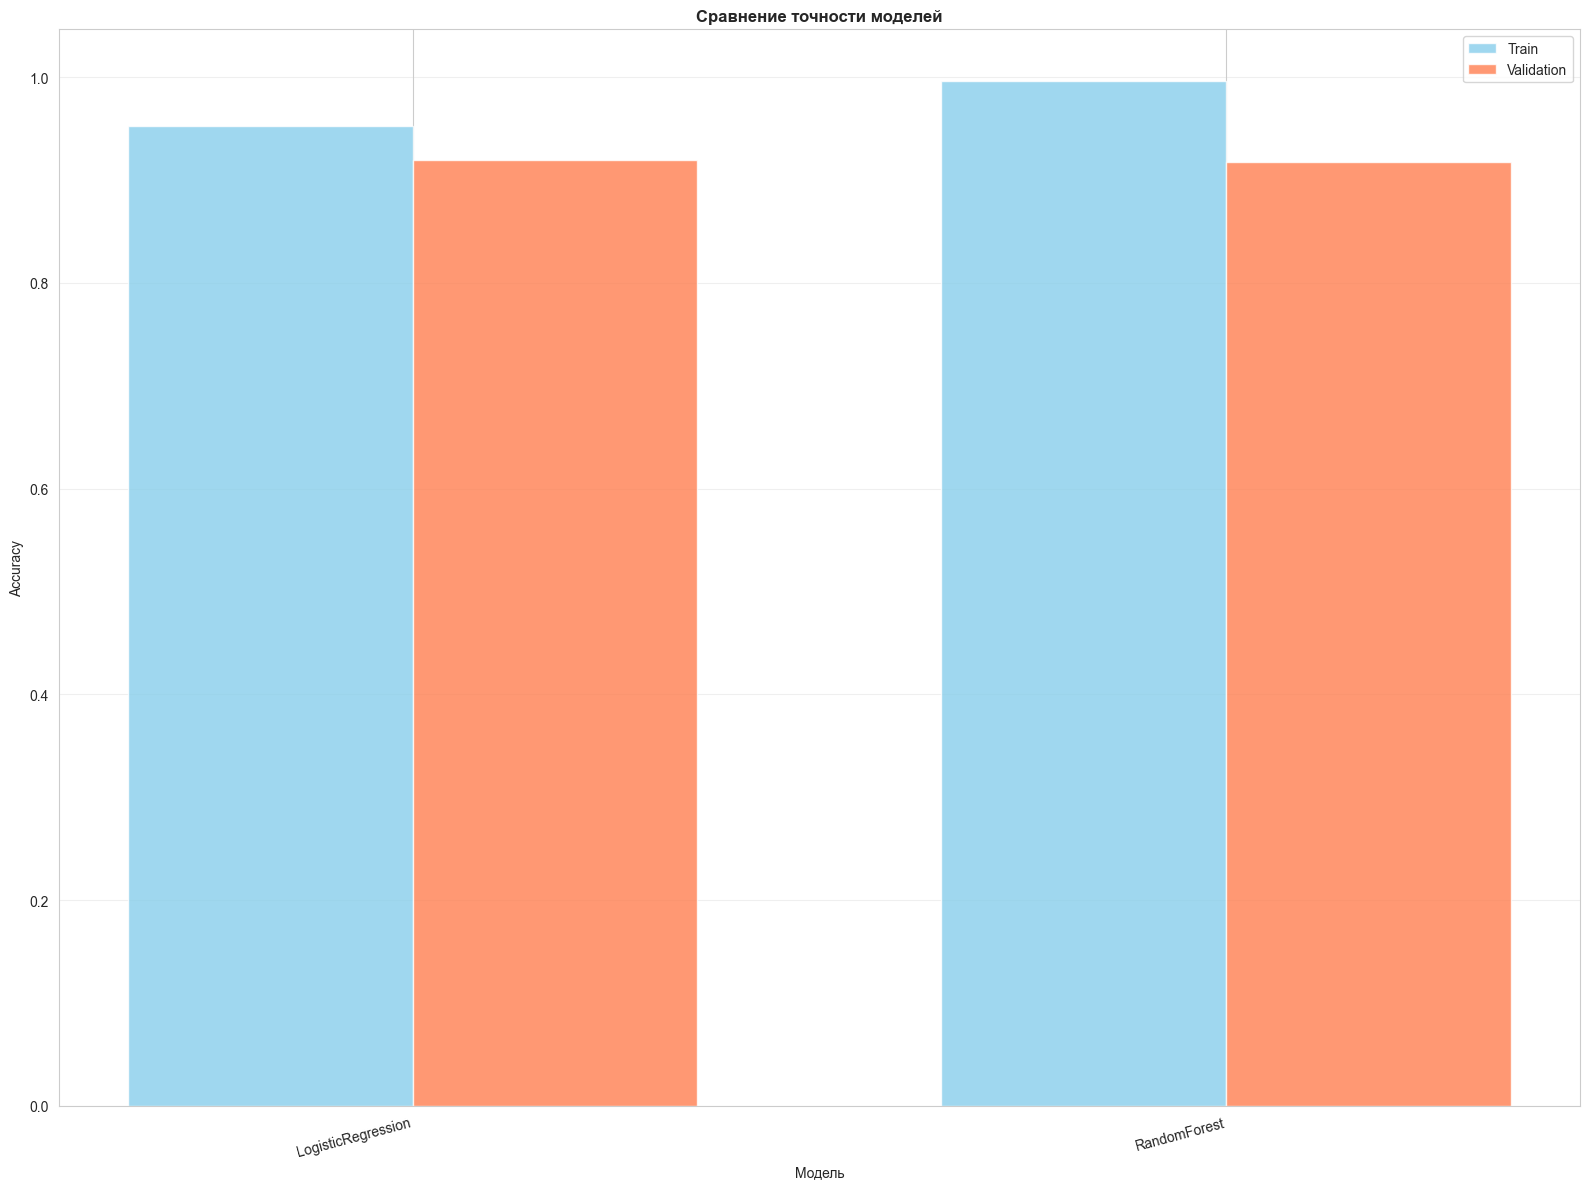

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

model_names = list(results.keys())
train_accs = [results[name]["train_acc"] for name in model_names]
val_accs = [results[name]["val_acc"] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

ax.bar(x - width / 2, train_accs, width, label="Train", alpha=0.8, color="skyblue")
ax.bar(x + width / 2, val_accs, width, label="Validation", alpha=0.8, color="coral")
ax.set_xlabel("Модель")
ax.set_ylabel("Accuracy")
ax.set_title("Сравнение точности моделей", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("./assets/models_scores_w2v.png", dpi=300)

In [ ]:
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, name in zip(axes, models.keys()):
    model_name = name.lower().replace(" ", "_")
    with open(f"models/{model_name}_model.pkl", "rb") as f:
        clf = pickle.load(f)
    y_val_pred = clf.predict(X_val)
    cm = confusion_matrix(y_val, y_val_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
        xticklabels=["Фейк", "Реальная"],
        yticklabels=["Фейк", "Реальная"],
        annot_kws={"size": 14},
    )
    acc = (y_val_pred == y_val).mean()
    ax.set_title(f"{name}\n(accuracy={acc:.4f})", fontsize=11)
    ax.set_xlabel("Предсказание")
    ax.set_ylabel("Истина")

plt.suptitle(
    "Матрицы ошибок: классические модели на Word2Vec",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
Path("assets").mkdir(exist_ok=True)
plt.savefig("./assets/confusion_matrices_w2v.png", dpi=200, bbox_inches="tight")
plt.show()

# TF-IDF

## Разделим данные

In [29]:
X = train_data_tf["combined_text"]
y = train_data_tf["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
print(f"\nРаспределение классов в train:")
print(y_train.value_counts())
print(f"\nРаспределение классов в validation:")
print(y_val.value_counts())


Распределение классов в train:
label
0    1777
1    1749
Name: count, dtype: int64

Распределение классов в validation:
label
0    444
1    438
Name: count, dtype: int64


## Векторизация

In [31]:
vectorizer = TfidfVectorizer(
    max_features=8000, ngram_range=(1, 2), min_df=3, max_df=0.85, sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

print(f"✓ Размерность векторов: {X_train_vec.shape[1]} признаков")
print(
    f"✓ Разреженность: {(1 - X_train_vec.nnz / (X_train_vec.shape[0] * X_train_vec.shape[1])) * 100:.2f}%"
)

✓ Размерность векторов: 8000 признаков
✓ Разреженность: 98.97%


## Обучим 3 модели и в последствии выберем лучшую
---
* Logistic Regression
* Naive Bayes
* Random Forest

In [32]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
}

In [33]:
param_grids = {
    "Logistic Regression": {
        "C": [0.1, 0.5, 1, 2, 5],
        "solver": ["liblinear", "lbfgs"],
        "max_iter": [500, 1000, 2000],
        "class_weight": ["balanced", None],
    },
    "Naive Bayes": {"alpha": [0.01, 0.1, 0.5, 1.0]},
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [10, 20, 30, None],
        "min_samples_split": [2, 5, 10],
        "class_weight": ["balanced"],
    },
}

In [34]:
results = {}
metrics_dict = {}

# Цикл по моделям с подбором гиперпараметров
for name, model in models.items():
    print(f"\n--- {name}: подбор гиперпараметров ---")

    grid = GridSearchCV(
        model, param_grids[name], cv=3, scoring="f1_weighted", n_jobs=-1, verbose=1
    )
    grid.fit(X_train_vec, y_train)

    best_model = grid.best_estimator_

    # Предсказания
    y_train_pred = best_model.predict(X_train_vec)
    y_val_pred = best_model.predict(X_val_vec)

    # Метрики
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average="weighted")

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")
    print("\nClassification Report:")
    print(
        classification_report(
            y_val,
            y_val_pred,
            target_names=["Фейк (disagree)", "Реальная (agree)"],
            digits=4,
        )
    )

    # Сохраняем результаты и модели
    model_name = name.lower().replace(" ", "_")
    results[name] = {
        "best_params": grid.best_params_,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "val_f1": val_f1,
    }
    metrics_dict[model_name] = {
        "val_acc": val_acc,
        "val_f1": val_f1,
        "best_params": grid.best_params_,
    }

    with open(f"models/{model_name}_model_tf.pkl", "wb") as f:
        pickle.dump(best_model, f)

# Сохраняем метрики в JSON
with open("results/metrics/metrics_tfidf_tuned.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

print("\nПодбор гиперпараметров завершён успешно!")


--- Logistic Regression: подбор гиперпараметров ---
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Лучшие параметры: {'C': 5, 'class_weight': 'balanced', 'max_iter': 500, 'solver': 'lbfgs'}
Train Accuracy: 0.9983
Val Accuracy:   0.9603
Val F1-Score:   0.9603

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9455    0.9775    0.9612       444
Реальная (agree)     0.9764    0.9429    0.9593       438

        accuracy                         0.9603       882
       macro avg     0.9609    0.9602    0.9603       882
    weighted avg     0.9608    0.9603    0.9603       882


--- Naive Bayes: подбор гиперпараметров ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Лучшие параметры: {'alpha': 1.0}
Train Accuracy: 0.9606
Val Accuracy:   0.9365
Val F1-Score:   0.9364

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9145    0.9640    0.9386       444
Ре

## Проверим на метриках

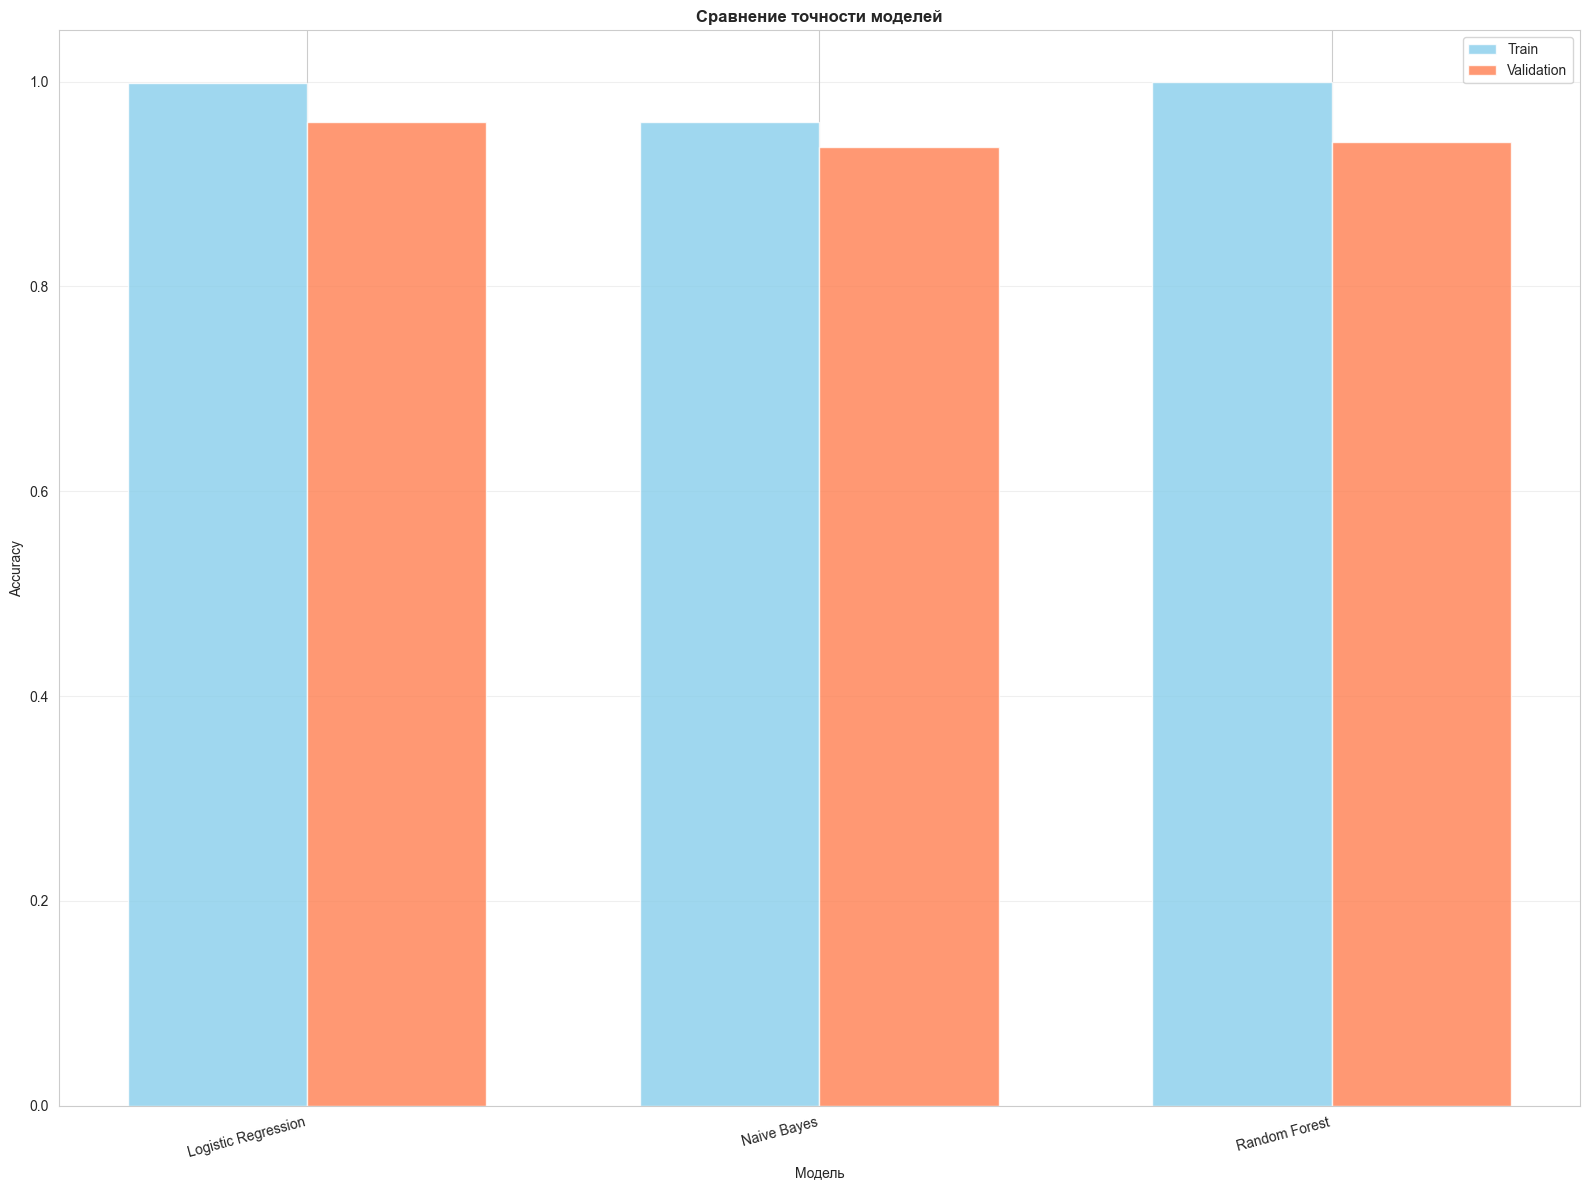

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

model_names = list(results.keys())
train_accs = [results[name]["train_acc"] for name in model_names]
val_accs = [results[name]["val_acc"] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

ax.bar(x - width / 2, train_accs, width, label="Train", alpha=0.8, color="skyblue")
ax.bar(x + width / 2, val_accs, width, label="Validation", alpha=0.8, color="coral")
ax.set_xlabel("Модель")
ax.set_ylabel("Accuracy")
ax.set_title("Сравнение точности моделей", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("./assets/models_scores.png", dpi=300)

In [ ]:
fig, axes = plt.subplots(1, len(models), figsize=(5.5 * len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, name in zip(axes, models.keys()):
    model_name = name.lower().replace(" ", "_")
    with open(f"models/{model_name}_model_tf.pkl", "rb") as f:
        clf = pickle.load(f)
    y_val_pred = clf.predict(X_val_vec)
    cm = confusion_matrix(y_val, y_val_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False,
        xticklabels=["Фейк", "Реальная"],
        yticklabels=["Фейк", "Реальная"],
        annot_kws={"size": 14},
    )
    acc = (y_val_pred == y_val).mean()
    ax.set_title(f"{name}\n(accuracy={acc:.4f})", fontsize=11)
    ax.set_xlabel("Предсказание")
    ax.set_ylabel("Истина")

plt.suptitle(
    "Матрицы ошибок: классические модели на TF-IDF",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
Path("assets").mkdir(exist_ok=True)
plt.savefig("./assets/confusion_matrices_tfidf.png", dpi=200, bbox_inches="tight")
plt.show()

In [36]:
train_data["text_length"] = train_data["combined_text"].str.split().str.len()

train_data_tf = train_data

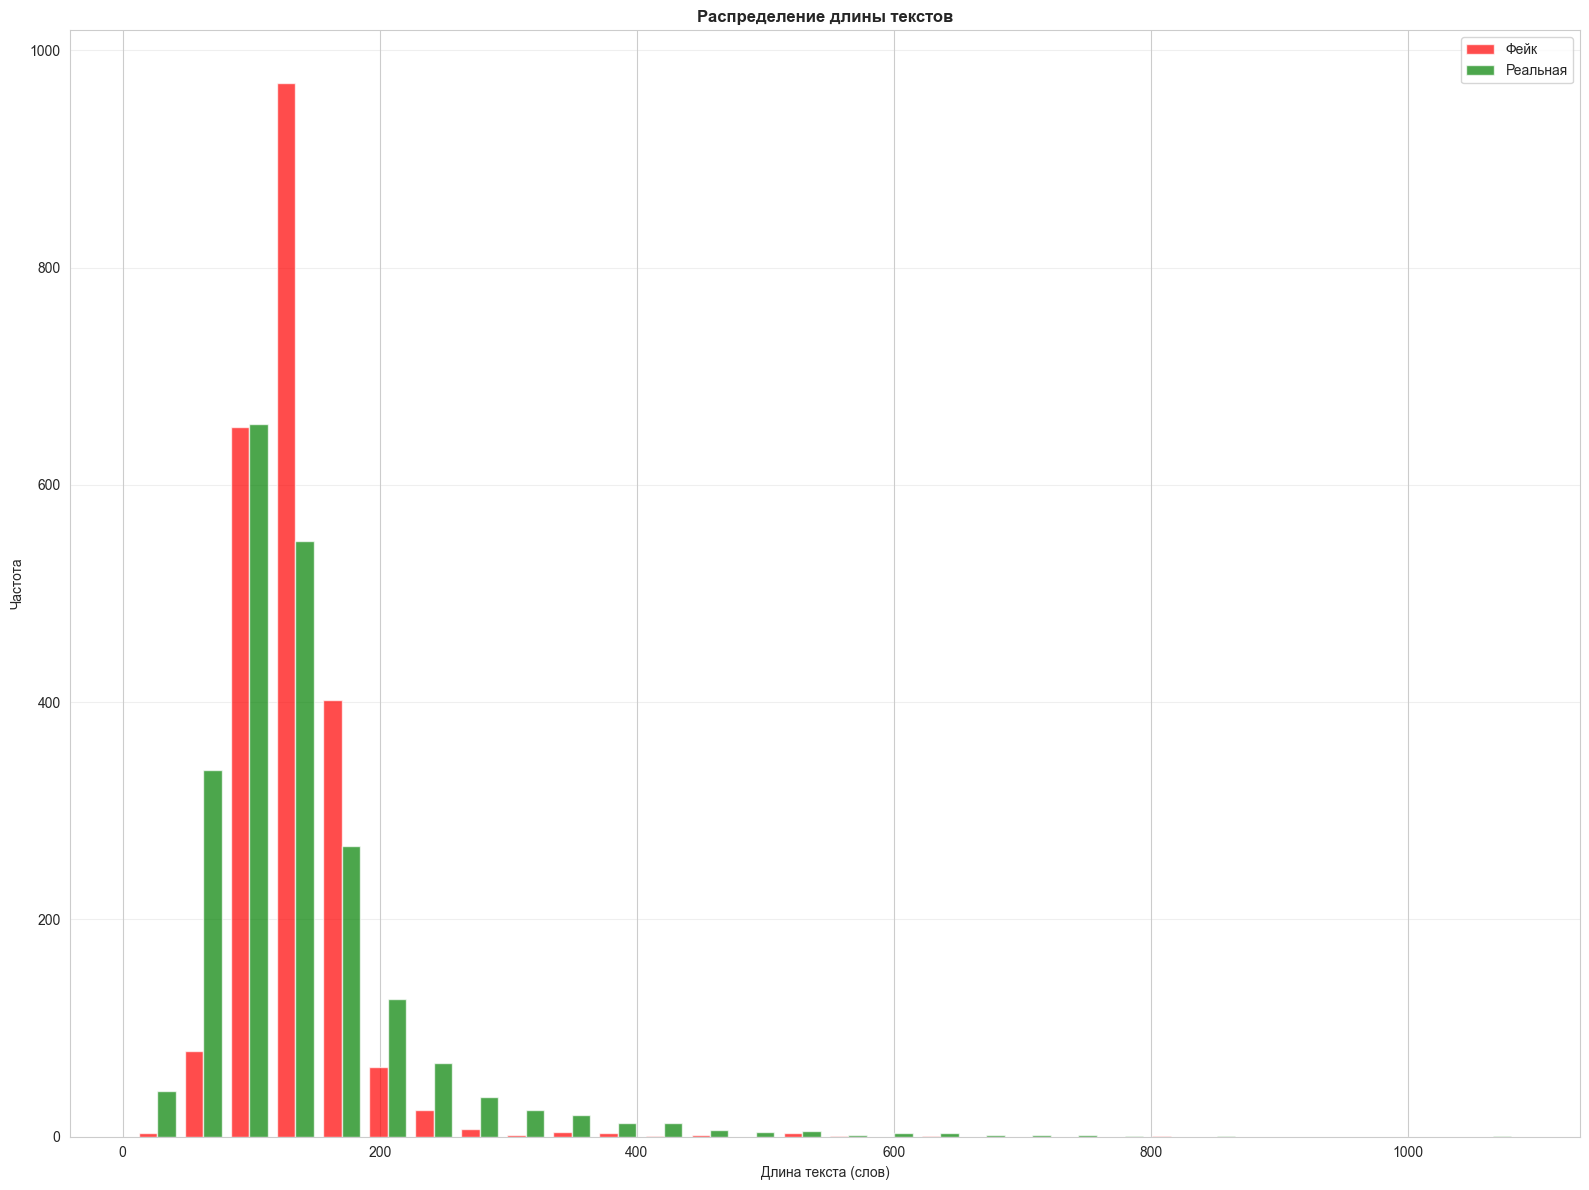

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

ax.hist(
    [
        train_data_tf[train_data_tf["label"] == 0]["text_length"],
        train_data_tf[train_data_tf["label"] == 1]["text_length"],
    ],
    bins=30,
    label=["Фейк", "Реальная"],
    alpha=0.7,
    color=["red", "green"],
)
ax.set_xlabel("Длина текста (слов)")
ax.set_ylabel("Частота")
ax.set_title("Распределение длины текстов", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("./assets/text_lenght.png", dpi=300)

## Сохраним модели

In [38]:
# for name, info in results.items():
#     model = info['models']
#     filename = f'./models/{name}_model_tf.pkl'
#     with open(filename, 'wb') as f:
#         pickle.dump(model, f)
#     print(f"Модель {name} сохранена в {filename}")

# Также сохраняем векторизатор и лейблы (общие для всех моделей)
with open("./models/tfidf_vectorizer_tf.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("./models/label_mapping_tf.pkl", "wb") as f:
    pickle.dump(label_mapping, f)

In [39]:
from pathlib import Path

# Формируем словарь метрик
metrics = {
    model_name: {"val_acc": results[model_name]["val_acc"]} for model_name in results
}

# Создаём каталог, если его нет
Path("results/metrics").mkdir(parents=True, exist_ok=True)

# Сохраняем метрики в JSON
with open("results/metrics/metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("Метрики сохранены в results/metrics/metrics.json")

Метрики сохранены в results/metrics/metrics.json


# TF-IDF на английском датасете (Обработка датасета выше)

In [40]:
sentences = [text.split() for text in eng_data["body_clean"]] + [
    text.split() for text in eng_data["headline_clean"]
]
w2v = Word2Vec(
    sentences, vector_size=300, window=3, min_count=3, sg=1, workers=4, epochs=10
)
kv = w2v.wv

In [41]:
eng_data["text_length"] = eng_data["combined_text"].str.split().str.len()
eng_data.sample(3)

,Headline,articleBody,label,headline_clean,body_clean,combined_text,text_length
26673,Putin critic Navalny clears first hurdle in bi...,MOSCOW (Reuters) - Russian opposition leader A...,1,putin critic navalny clears first hurdle bid r...,moscow reuters russian opposition leader alexe...,putin critic navalny clears first hurdle bid r...,259
7203,"Venezuela governors sworn in, showing oppositi...",CARACAS (Reuters) - In another setback for Ven...,1,venezuela governors sworn showing opposition d...,caracas reuters another setback venezuela disp...,venezuela governors sworn showing opposition d...,327
10396,WHY WAS THIS YOUNG MAN SPONSORED BY CAIR INVIT...,It s Hard To Know Who Obama Hates More America...,0,young man sponsored cair invited white house,hard know obama hates america israel police of...,young man sponsored cair invited white house h...,304


In [42]:
X = eng_data["combined_text"]
y = eng_data["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [43]:
vectorizer = TfidfVectorizer(
    max_features=8000, ngram_range=(1, 2), min_df=3, max_df=0.85, sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

print(f"✓ Размерность векторов: {X_train_vec.shape[1]} признаков")
print(
    f"✓ Разреженность: {(1 - X_train_vec.nnz / (X_train_vec.shape[0] * X_train_vec.shape[1])) * 100:.2f}%"
)

✓ Размерность векторов: 8000 признаков
✓ Разреженность: 98.05%


In [44]:
results = {}
metrics_dict = {}

# Цикл по моделям с подбором гиперпараметров
for name, model in models.items():
    print(f"\n--- {name}: подбор гиперпараметров ---")

    grid = GridSearchCV(
        model, param_grids[name], cv=3, scoring="f1_weighted", n_jobs=2, verbose=1
    )
    grid.fit(X_train_vec, y_train)

    best_model = grid.best_estimator_

    # Предсказания
    y_train_pred = best_model.predict(X_train_vec)
    y_val_pred = best_model.predict(X_val_vec)

    # Метрики
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average="weighted")

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")
    print("\nClassification Report:")
    print(
        classification_report(
            y_val,
            y_val_pred,
            target_names=["Фейк (disagree)", "Реальная (agree)"],
            digits=4,
        )
    )

    # Сохраняем результаты и модели
    model_name = name.lower().replace(" ", "_")
    results[name] = {
        "best_params": grid.best_params_,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "val_f1": val_f1,
    }
    metrics_dict[model_name] = {
        "val_acc": val_acc,
        "val_f1": val_f1,
        "best_params": grid.best_params_,
    }

    with open(f"models/{model_name}_model_tf_eng.pkl", "wb") as f:
        pickle.dump(best_model, f)

# Сохраняем метрики в JSON
with open("results/metrics/metrics_tfidf_eng.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

print("\nПодбор гиперпараметров завершён успешно!")


--- Logistic Regression: подбор гиперпараметров ---
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Лучшие параметры: {'C': 5, 'class_weight': None, 'max_iter': 500, 'solver': 'liblinear'}
Train Accuracy: 0.9992
Val Accuracy:   0.9968
Val F1-Score:   0.9968

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9994    0.9955    0.9974      3328
Реальная (agree)     0.9927    0.9990    0.9958      2029

        accuracy                         0.9968      5357
       macro avg     0.9960    0.9973    0.9966      5357
    weighted avg     0.9968    0.9968    0.9968      5357


--- Naive Bayes: подбор гиперпараметров ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Лучшие параметры: {'alpha': 0.01}
Train Accuracy: 0.9861
Val Accuracy:   0.9854
Val F1-Score:   0.9855

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9921    0.9844    0.9882      3328
Реа

In [45]:
with open("./models/tfidf_vectorizer_tf_eng.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("./models/label_mapping_tf_eng.pkl", "wb") as f:
    pickle.dump(label_mapping, f)

# Word2Vec на английском датасете

In [46]:
sentences = [text.split() for text in eng_data["body_clean"]] + [
    text.split() for text in eng_data["headline_clean"]
]
w2v = Word2Vec(
    sentences, vector_size=300, window=3, min_count=3, sg=1, workers=4, epochs=10
)
kv = w2v.wv

In [47]:
def docvector(tokens, kvmodel):
    vecs = [kvmodel[w] for w in tokens if w in kvmodel]
    if not vecs:
        return np.zeros(kvmodel.vector_size, dtype=np.float32)
    return np.vstack(vecs).mean(axis=0)


def buildfeatures(df, kv, maxlen=150):
    H, B, COS, JAC, OVR, L2, DIFF, PROD = [], [], [], [], [], [], [], []
    for i, row in df.iterrows():
        htoks = row["headline_clean"].split()[:maxlen]
        btoks = row["body_clean"].split()[:maxlen]
        hvec = docvector(htoks, kv)
        bvec = docvector(btoks, kv)
        H.append(hvec)
        B.append(bvec)
        COS.append(
            float(
                np.dot(hvec, bvec)
                / (np.linalg.norm(hvec) * np.linalg.norm(bvec) + 1e-9)
            )
        )
    X = np.hstack([np.vstack(H), np.vstack(B), np.array(COS).reshape(-1, 1)])
    return X

In [48]:
X = buildfeatures(eng_data, kv)
y = eng_data["label"].values
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [49]:
models = {
    "LogisticRegression": LogisticRegression(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),
}

Path("models").mkdir(parents=True, exist_ok=True)

In [50]:
param_grids = {
    "LogisticRegression": {
        "C": [0.1, 0.5, 1, 2, 5],
        "solver": ["liblinear", "lbfgs"],
        "max_iter": [500, 1000, 2000],
        "class_weight": ["balanced", None],
    },
    "RandomForest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [10, 20, 30, None],
        "min_samples_split": [2, 5, 10],
        "class_weight": ["balanced"],
    },
}

In [51]:
results = {}
metrics_dict = {}

for name, model in models.items():
    print(f"\n--- {name}: подбор гиперпараметров ---")

    grid = GridSearchCV(
        model, param_grids[name], cv=3, scoring="f1_weighted", n_jobs=2, verbose=1
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    # Предсказания
    y_train_pred = best_model.predict(X_train)
    y_val_pred = best_model.predict(X_val)

    # Метрики
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average="weighted")

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")
    print("\nClassification Report:")
    print(
        classification_report(
            y_val,
            y_val_pred,
            target_names=["Фейк (disagree)", "Реальная (agree)"],
            digits=4,
        )
    )

    # Сохранение модели
    model_name = name.lower().replace(" ", "_")
    with open(f"models/{model_name}_model_w2v_eng.pkl", "wb") as f:
        pickle.dump(best_model, f)

    results[name] = {
        "best_params": grid.best_params_,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "val_f1": val_f1,
    }

    metrics_dict[model_name] = {
        "val_accuracy": val_acc,
        "val_f1": val_f1,
        "best_params": grid.best_params_,
    }

Path("results/metrics").mkdir(parents=True, exist_ok=True)
with open("results/metrics/metrics_w2v_eng.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

# Эмбеддинги
kv.save("models/w2v_vectors_eng.kv")


--- LogisticRegression: подбор гиперпараметров ---
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Лучшие параметры: {'C': 5, 'class_weight': None, 'max_iter': 500, 'solver': 'liblinear'}
Train Accuracy: 0.9968
Val Accuracy:   0.9920
Val F1-Score:   0.9920

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9928    0.9943    0.9935      3328
Реальная (agree)     0.9906    0.9882    0.9894      2029

        accuracy                         0.9920      5357
       macro avg     0.9917    0.9912    0.9915      5357
    weighted avg     0.9920    0.9920    0.9920      5357


--- RandomForest: подбор гиперпараметров ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
Train Accuracy: 0.9996
Val Accuracy:   0.9830
Val F1-Score:   0.9830

Classification Report:
                  precision    recall  f1-s

# Итоговая матрица ошибок всех пяти классических моделей

Единая фигура с матрицами ошибок всех пяти классических моделей (TF-IDF + Word2Vec) на одной и той же валидационной выборке (русский датасет, тот же 80/20 split, random_state=42).

In [ ]:
# Восстанавливаем валидационную выборку русского датасета,
# поскольку переменные X_val/y_val были перезаписаны в секциях TF-IDF и English.
from sklearn.model_selection import train_test_split

X_idx = train_data.index.values
y_all = train_data["label"].values
_, idx_val, _, y_val_full = train_test_split(
    X_idx, y_all, test_size=0.2, random_state=42, stratify=y_all
)
val_df = train_data.loc[idx_val].reset_index(drop=True)
y_val_full = val_df["label"].values

# TF-IDF предсказания
vec_tf = pickle.load(open("models/tfidf_vectorizer_tf.pkl", "rb"))
X_val_tf = vec_tf.transform(val_df["combined_text"].astype(str))
preds_tfidf = {}
for display_name, file_name in [
    ("LR + TF-IDF",  "logistic_regression_model_tf.pkl"),
    ("NB + TF-IDF",  "naive_bayes_model_tf.pkl"),
    ("RF + TF-IDF",  "random_forest_model_tf.pkl"),
]:
    clf = pickle.load(open(f"models/{file_name}", "rb"))
    preds_tfidf[display_name] = clf.predict(X_val_tf)

# Word2Vec предсказания
kv_ru = KeyedVectors.load("models/w2v_vectors.kv")
X_val_w2v = build_features(val_df, kv_ru)
preds_w2v = {}
for display_name, file_name in [
    ("LR + Word2Vec", "logisticregression_model.pkl"),
    ("RF + Word2Vec", "randomforest_model.pkl"),
]:
    clf = pickle.load(open(f"models/{file_name}", "rb"))
    preds_w2v[display_name] = clf.predict(X_val_w2v)

all_preds = {**preds_tfidf, **preds_w2v}

# Единая фигура: 5 матриц ошибок в одной строке
fig, axes = plt.subplots(1, len(all_preds), figsize=(4.5 * len(all_preds), 4.6))
for ax, (name, y_pred) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_val_full, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Фейк", "Реальная"],
                yticklabels=["Фейк", "Реальная"],
                annot_kws={"size": 13})
    acc = (y_pred == y_val_full).mean()
    ax.set_title(f"{name}
(accuracy={acc:.4f})", fontsize=11)
    ax.set_xlabel("Предсказание")
    ax.set_ylabel("Истина")

plt.suptitle("Матрицы ошибок всех пяти классических моделей",
             fontsize=15, fontweight="bold", y=1.04)
plt.tight_layout()
Path("assets").mkdir(exist_ok=True)
plt.savefig("./assets/confusion_matrices_all_classical.png", dpi=200, bbox_inches="tight")
plt.show()
